# Learned edge selection with GBDT (IMC25)

This notebook implements learned edge scoring for the clustering / pair-selection stage.

- Uses given global embeddings (pretrained or finetuned DINO) as input
- script then generates candidate edges via KNN (also implemented in pipeline)
- script then trains a Gradient Boosted Decision Tree (GBDT) and an Edge MLP model to predict whether an edge connects images from the same scene.
- Params for the Edge MLP Model have been finetuned

In [54]:
from __future__ import annotations

import random
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
)


def _find_repo_root() -> Path:
    p = Path.cwd().resolve()
    while p != p.parent:
        if (p / "src").exists() and (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("Could not find repo root (expected src/ and pyproject.toml)")


REPO_ROOT = _find_repo_root()
CACHE_ROOT = REPO_ROOT / "cache"
OUT_ROOT = REPO_ROOT / "outputs" / "edge_models"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

SEED = 42
VAL_RATIO = 0.1
K = 30

#EdgeMLP
BATCH_SIZE = 1024
EPOCHS = 20
LR = 1e-3

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

## Load Embeddings

In [55]:
def load_all_embeddings(cache_root: Path):
    Z_list = []
    scene_labels = []

    for scene_dir in sorted(cache_root.iterdir()):
        if not scene_dir.is_dir():
            continue
        emb_path = scene_dir / "embeddings.npy"
        if not emb_path.exists():
            continue

        Z_scene = np.load(emb_path).astype(np.float32)
        Z_list.append(Z_scene)
        scene_labels.extend([scene_dir.name] * Z_scene.shape[0])

    if not Z_list:
        raise RuntimeError("No embeddings found.")

    Z = np.vstack(Z_list)
    scenes = sorted(set(scene_labels))
    scene_to_id = {s: i for i, s in enumerate(scenes)}
    y = np.array([scene_to_id[s] for s in scene_labels], dtype=np.int32)

    return Z, y, scenes


## Build candidate edges (pairs) via KNN
Edge selection happens here: 
- first generate candidate pairs using KNN on the embeddings.
- The either the heuristic threshold/learned GBDT classifier/learned MLP classifier decides which pairs to keep


In [56]:
def knn_indices(Z: np.ndarray, k: int):
    sim = Z @ Z.T
    np.fill_diagonal(sim, -1.0)
    k = min(k, Z.shape[0] - 1)
    idx = np.argpartition(-sim, kth=k, axis=1)[:, :k]
    row = np.arange(Z.shape[0])[:, None]
    idx = idx[row, np.argsort(-sim[row, idx], axis=1)]
    return idx.astype(np.int32)

def build_edge_table(Z: np.ndarray, y: np.ndarray, k: int):
    idx = knn_indices(Z, k)
    rank_maps = [{int(j): r for r, j in enumerate(idx[i])} for i in range(len(idx))]

    rows = []
    for i in range(len(idx)):
        for r_ij, j in enumerate(idx[i]):
            j = int(j)
            same = int(y[i] == y[j])
            cos = float(Z[i] @ Z[j])
            r_ji = rank_maps[j].get(i, -1)
            mutual = int(r_ji >= 0)
            rows.append((i, j, cos, r_ij, r_ji, mutual, same))

    return pd.DataFrame(
        rows,
        columns=["i", "j", "cos", "rank_ij", "rank_ji", "mutual", "same_scene"],
    )


## Split images
- Train/Val Split

In [57]:
def split_images(N, val_ratio, seed):
    idx = np.arange(N)
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    n_val = int(round(N * val_ratio))
    return set(idx[n_val:]), set(idx[:n_val])

## Metrics

In [58]:
def edge_recall_at_k(edges: pd.DataFrame, scores: np.ndarray, K=5):
    hits = []
    for i, g in edges.groupby("i"):
        topk = np.argsort(-scores[g.index])[:K]
        hits.append(int(g.iloc[topk]["same_scene"].any()))
    return np.mean(hits)

def plot_roc(y, scores: dict[str, np.ndarray]):
    plt.figure(figsize=(5, 5))
    for name, s in scores.items():
        fpr, tpr, _ = roc_curve(y, s)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y, s):.3f})")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("Edge ROC comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


# GDBT Model
- Implementation of a Gradient Boosted Decision Tree for edge classification

In [59]:
def make_X(df: pd.DataFrame):
    inv_ij = 1.0 / (df["rank_ij"].to_numpy(np.float32) + 1.0)

    rji = df["rank_ji"].to_numpy(np.float32)
    inv_ji = np.zeros_like(rji)
    mask = rji >= 0
    inv_ji[mask] = 1.0 / (rji[mask] + 1.0)

    X = np.stack(
        [
            df["cos"].to_numpy(np.float32),
            inv_ij,
            inv_ji,
            df["mutual"].to_numpy(np.float32),
        ],
        axis=1,
    )
    return X

def train_gbdt(edges_tr: pd.DataFrame):
    X = make_X(edges_tr)
    y = edges_tr["same_scene"].to_numpy()
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    w = np.where(y == 1, neg / max(pos, 1), 1.0)

    model = HistGradientBoostingClassifier(
        max_depth=5,
        max_leaf_nodes=31,
        learning_rate=0.05,
        max_iter=400,
        random_state=SEED,
    )
    model.fit(X, y, sample_weight=w)
    return model

# Edge MLP Model

In [60]:
class EdgeMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2 * d + 1, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, zi, zj):
        cos = F.cosine_similarity(zi, zj).unsqueeze(1)
        x = torch.cat([zi * zj, torch.abs(zi - zj), cos], dim=1)
        return torch.sigmoid(self.net(x)).squeeze(1)

# Main: 
- Executing trainig and evaluation

Images: 648 Scenes: 5
Val anchors with any positive candidate: 0.90625
Epoch 01 | EdgeMLP loss 0.6140
Epoch 02 | EdgeMLP loss 0.4746
Epoch 03 | EdgeMLP loss 0.2972
Epoch 04 | EdgeMLP loss 0.2183
Epoch 05 | EdgeMLP loss 0.1915
Epoch 06 | EdgeMLP loss 0.1114
Epoch 07 | EdgeMLP loss 0.0893
Epoch 08 | EdgeMLP loss 0.1145
Epoch 09 | EdgeMLP loss 0.1227
Epoch 10 | EdgeMLP loss 0.1018
Epoch 11 | EdgeMLP loss 0.0654
Epoch 12 | EdgeMLP loss 0.0655
Epoch 13 | EdgeMLP loss 0.0566
Epoch 14 | EdgeMLP loss 0.0385
Epoch 15 | EdgeMLP loss 0.0439
Epoch 16 | EdgeMLP loss 0.0603
Epoch 17 | EdgeMLP loss 0.0641
Epoch 18 | EdgeMLP loss 0.0242
Epoch 19 | EdgeMLP loss 0.0560
Epoch 20 | EdgeMLP loss 0.0203
      model       auc        ap       r@1      r@3      r@5
0    cosine  0.852799  0.976788  0.828125  0.90625  0.90625
1      gbdt  0.859473  0.977925  0.843750  0.90625  0.90625
2  edge_mlp  0.976826  0.996320  0.875000  0.90625  0.90625


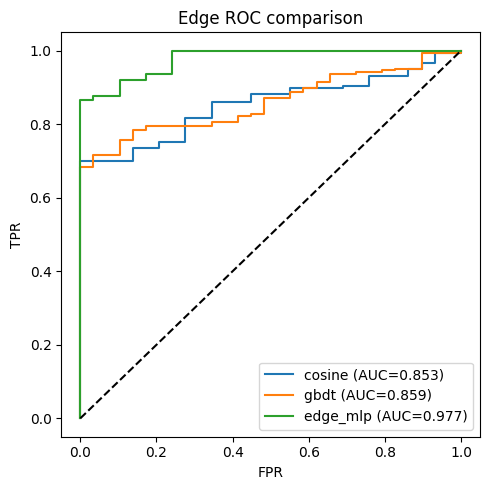

In [64]:
def main():
    Z, y, scenes = load_all_embeddings(CACHE_ROOT)
    print("Images:", len(Z), "Scenes:", len(scenes))

    train_idx, val_idx = split_images(len(Z), VAL_RATIO, SEED)

    edges = build_edge_table(Z, y, K)
    edges_tr = edges[edges["i"].isin(train_idx) & edges["j"].isin(train_idx)].reset_index(drop=True)
    edges_va = edges[edges["i"].isin(val_idx) & edges["j"].isin(val_idx)].reset_index(drop=True)

    def pos_available_rate(edges: pd.DataFrame) -> float:
        # fraction of anchors i that have at least one positive candidate
        has_pos = edges.groupby("i")["same_scene"].max()
        return float(has_pos.mean())

    print(
        "Val anchors with any positive candidate:",
        pos_available_rate(edges_va),
    )

    # heuristic
    score_cos = edges_va["cos"].to_numpy()

    # GBDT 
    gbdt = train_gbdt(edges_tr)
    score_gbdt = gbdt.predict_proba(make_X(edges_va))[:, 1]

    # EdgeMLP 
    model = EdgeMLP(Z.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.BCELoss()

    Zt = torch.from_numpy(Z).to(DEVICE)
    i_tr = torch.from_numpy(edges_tr["i"].to_numpy()).to(DEVICE)
    j_tr = torch.from_numpy(edges_tr["j"].to_numpy()).to(DEVICE)
    y_tr = torch.from_numpy(edges_tr["same_scene"].to_numpy()).float().to(DEVICE)

    for epoch in range(EPOCHS):
        perm = torch.randperm(len(i_tr))
        for b in range(0, len(i_tr), BATCH_SIZE):
            idx = perm[b : b + BATCH_SIZE]
            pred = model(Zt[i_tr[idx]], Zt[j_tr[idx]])
            loss = loss_fn(pred, y_tr[idx])
            opt.zero_grad()
            loss.backward()
            opt.step()
        print(f"Epoch {epoch+1:02d} | EdgeMLP loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        score_mlp = (
            model(
                Zt[edges_va["i"].to_numpy()],
                Zt[edges_va["j"].to_numpy()],
            )
            .cpu()
            .numpy()
        )

    # evaluation 
    yva = edges_va["same_scene"].to_numpy()

    results = []
    for name, score in [
        ("cosine", score_cos),
        ("gbdt", score_gbdt),
        ("edge_mlp", score_mlp),
    ]:
        results.append(
        {
            "model": name,
            "auc": roc_auc_score(yva, score),
            "ap": average_precision_score(yva, score),
            "r@1": edge_recall_at_k(edges_va, score, K=1),
            "r@3": edge_recall_at_k(edges_va, score, K=3),
            "r@5": edge_recall_at_k(edges_va, score, K=5)
        }
    )

    df = pd.DataFrame(results)
    print(df)

    plot_roc(
        yva,
        {
            "cosine": score_cos,
            "gbdt": score_gbdt,
            "edge_mlp": score_mlp,
        },
    )

    # saving results
    joblib.dump(
        {
            "gbdt": gbdt,
            "K": K,
        },
        OUT_ROOT / "edge_gbdt.joblib",
    )

    torch.save(
        {
            "state_dict": model.state_dict(),
            "dim": Z.shape[1],
            "K": K,
        },
        OUT_ROOT / "edge_mlp.pt",
    )

    df.to_csv(OUT_ROOT / "comparison_metrics.csv", index=False)

if __name__ == "__main__":
    main()